In [14]:
import os
import tensorly as tl
random_state=42

os.environ["TENSORLY_BACKEND"] = 'numpy'
tl.set_backend('numpy')
print(tl.get_backend())
%pip freeze | grep moabb

numpy
moabb==1.0.0
Note: you may need to restart the kernel to use updated packages.


In [15]:
from moabb.paradigms import P300
from moabb.datasets import *
from moabb.evaluations import WithinSessionEvaluation



paradigm = P300(resample=48)
dataset = BI2015b()


In [16]:
hoda_params = dict(
    max_iter=128,
    tol=1e-16,
    init ='eye',
    shrinkage='lw',
    toeplitz=None,
    obj='rt',
    solver='lanczos',
    taper=True,
    extra_train_info=False,
    verbose=False, 
    random_state=random_state,
)

In [17]:

from hoda.hoda import HODA,BTTDA
from sklearn.model_selection import GridSearchCV, cross_val_score
from hoda.tensorize import Tensorize, Vectorize
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

In [18]:
from hoda.hoda import BTTDA, GreedyBTTDA
from hoda.classification import SelectF
max_blocks = 2

pipe = Pipeline([
    ('bttda', GreedyBTTDA(
        max_blocks=max_blocks,
        hoda_params=dict(
            **hoda_params,
            delta=None,
        ),
        extra_train_info=False,
        verbose=False,
        n_jobs=-1,
    )),
    ('clf', GreedyBTTDA.clf_pipe())
])

In [20]:
import math
from sklearn.metrics import roc_auc_score
import pandas as pd

block_results = []
for subject in [dataset.subject_list[5]]:
    #TODO: session
    print(f'subject={subject}')
    epochs, labels, meta = paradigm.get_data(
        dataset=dataset, 
        subjects=[subject],
        return_epochs=True
    )
    X = tl.tensor(epochs.get_data())
    y = labels
    result = cross_validate(pipe,X,y, cv=cv, return_estimator=True, return_indices=True, n_jobs=-1)
    for fold in range(cv.n_splits):
        bttda = result['estimator'][fold]['bttda']
        train_idc = result['indices']['train'][fold]
        test_idc = result['indices']['test'][fold]
        for n_blocks in range(1, max_blocks+1):
            Xt = bttda.transform(X, blocks=bttda.blocks_[:n_blocks])
            clf =  result['estimator'][fold]['clf']
            clf.fit(Xt[train_idc],y[train_idc])
            y_pred = clf.decision_function(Xt)
            roc_auc = roc_auc_score(y[test_idc],y_pred[test_idc])
            block_results.append(dict(
                subject=subject,
                fold=fold,
                n_blocks=n_blocks,
                roc_auc=roc_auc,
            ))
%time block_results = pd.DataFrame(block_results)

subject=6


/usr/local/lib/python3.10/dist-packages/moabb/datasets/download.py:55: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_BRAININVADERS2015B_PATH"
  set_config(key, get_config("MNE_DATA"))


Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
2640 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)
/tmp/ipykernel_4844/3364854858.py:14: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = tl.tensor(epochs.get_data())


CPU times: user 17.2 ms, sys: 47.4 ms, total: 64.6 ms
Wall time: 5.41 ms


In [21]:
index = ['subject', 'fold']
block_results = block_results.set_index(index)
df_group = block_results.groupby(index)
block_results['roc_auc_diff'] = block_results['roc_auc'] - df_group['roc_auc'].aggregate('first')
block_results = block_results.reset_index()
block_results

,subject,fold,n_blocks,roc_auc,roc_auc_diff
0,6,0,1,0.714844,0.000000
1,6,0,2,0.714844,0.000000
2,6,1,1,0.716966,0.000000
3,6,1,2,0.717568,0.000603
4,6,2,1,0.697362,0.000000
5,6,2,2,0.697362,0.000000
6,6,3,1,0.821494,0.000000
7,6,3,2,0.796803,-0.024691
8,6,4,1,0.784336,0.000000
9,6,4,2,0.784336,0.000000


/tmp/ipykernel_4844/2649342959.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=block_results, x='n_blocks', y='roc_auc_diff',


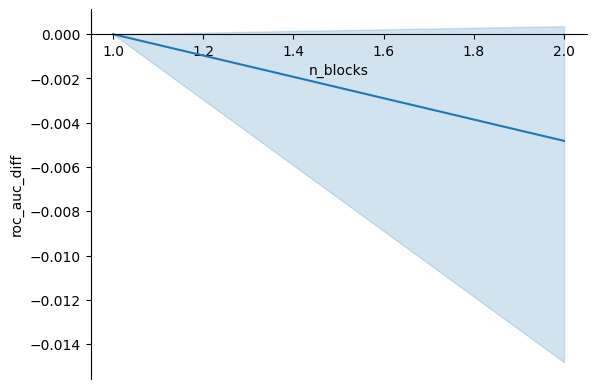

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('default')
sns.lineplot(data=block_results, x='n_blocks', y='roc_auc_diff',
             #hue='fold',
             palette='tab10',
             #ci=None
            )
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_position('zero')
#plt.axhline(res_hoda[0].mean(), color='red')

In [23]:
block_results.groupby('n_blocks')['roc_auc'].aggregate('mean')

n_blocks
1    0.747000
2    0.742183
Name: roc_auc, dtype: float64

In [24]:
block_results.groupby('n_blocks')['roc_auc'].aggregate('mean')

n_blocks
1    0.747000
2    0.742183
Name: roc_auc, dtype: float64

In [ ]:
"""
max_features = X[0].size
for i in range(math.ceil(math.sqrt(max_features/max_blocks))):
    n = max_blocks*(i**2)
    plt.plot([0, max_blocks], [0, n], color='lightgray')
plt.axhline(max_features, color='red')
plt.axhline(min(X[0].shape)**2, color='green')

sns.lineplot(data=block_results, x='n_blocks', y='n_features')
"""